<a href="https://colab.research.google.com/github/olcaykursun/ML/blob/main/Spring2026/denoising_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------------------------------
# Load MNIST
# -------------------------------------------------------

transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=128)

# -------------------------------------------------------
# Model
# -------------------------------------------------------

class MultiTaskNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classification head
        self.classifier = nn.Linear(32*7*7,10)

        # Denoising decoder
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(32,16,2,stride=2),   # 7 → 14
            nn.ReLU(),

            nn.ConvTranspose2d(16,1,2,stride=2),    # 14 → 28
            nn.Sigmoid()

        )

    def forward(self,x):

        z = self.encoder(x)

        # classification branch
        flat = z.view(z.size(0),-1)
        class_out = self.classifier(flat)

        # denoising branch
        recon = self.decoder(z)

        return class_out, recon


model = MultiTaskNet().to(device)

# -------------------------------------------------------
# Loss + optimizer
# -------------------------------------------------------

ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

noise_factor = 0.5

# -------------------------------------------------------
# Training
# -------------------------------------------------------

epochs = 10

for epoch in range(epochs):

    model.train()

    total_class_loss = 0
    total_denoise_loss = 0
    total_loss = 0
    batches = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        # add noise
        noise = noise_factor * torch.randn_like(x)
        x_noisy = torch.clamp(x + noise, 0, 1)

        class_pred, recon = model(x_noisy)

        loss_class = ce_loss(class_pred, y)
        loss_denoise = mse_loss(recon, x)

        loss = loss_class + loss_denoise

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_class_loss += loss_class.item()
        total_denoise_loss += loss_denoise.item()
        total_loss += loss.item()

        batches += 1

    print(
        f"Epoch {epoch+1} | "
        f"class_loss: {total_class_loss/batches:.4f} | "
        f"denoise_loss: {total_denoise_loss/batches:.4f} | "
        f"total_loss: {total_loss/batches:.4f}"
    )

# -------------------------------------------------------
# Evaluation
# -------------------------------------------------------

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)
        y = y.to(device)

        noise = noise_factor * torch.randn_like(x)
        x_noisy = torch.clamp(x + noise,0,1)

        class_pred, recon = model(x_noisy)

        preds = class_pred.argmax(dim=1)

        correct += (preds==y).sum().item()
        total += y.size(0)

print("Test accuracy:", correct/total)

Epoch 1 | class_loss: 0.6407 | denoise_loss: 0.0713 | total_loss: 0.7121
Epoch 2 | class_loss: 0.2502 | denoise_loss: 0.0248 | total_loss: 0.2750
Epoch 3 | class_loss: 0.1842 | denoise_loss: 0.0219 | total_loss: 0.2062
Epoch 4 | class_loss: 0.1620 | denoise_loss: 0.0204 | total_loss: 0.1824
Epoch 5 | class_loss: 0.1509 | denoise_loss: 0.0194 | total_loss: 0.1703
Epoch 6 | class_loss: 0.1391 | denoise_loss: 0.0188 | total_loss: 0.1579
Epoch 7 | class_loss: 0.1328 | denoise_loss: 0.0182 | total_loss: 0.1511
Epoch 8 | class_loss: 0.1295 | denoise_loss: 0.0179 | total_loss: 0.1474
Epoch 9 | class_loss: 0.1239 | denoise_loss: 0.0176 | total_loss: 0.1415
Epoch 10 | class_loss: 0.1179 | denoise_loss: 0.0174 | total_loss: 0.1353
Test accuracy: 0.9641


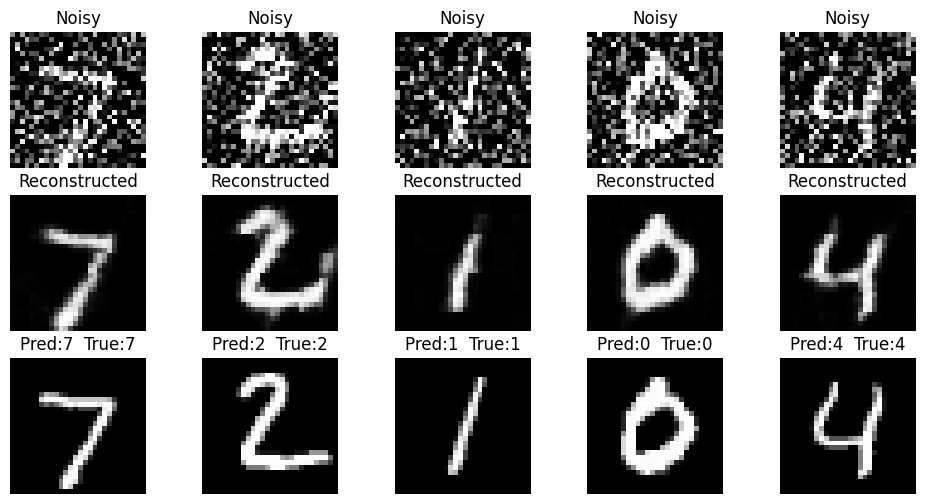

In [ ]:
# -------------------------------------------------------
# Visualize noisy images, reconstructions, and predictions
# -------------------------------------------------------

model.eval()

x, y = next(iter(test_loader))

noise = noise_factor * torch.randn_like(x)
x_noisy = torch.clamp(x + noise, 0, 1)

with torch.no_grad():
    class_pred, recon = model(x_noisy.to(device))

preds = class_pred.argmax(dim=1).cpu()
recon = recon.cpu()

n = 5

plt.figure(figsize=(12,6))

for i in range(n):

    # Noisy image
    plt.subplot(3, n, i+1)
    plt.imshow(x_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(3, n, i+1+n)
    plt.imshow(recon[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    # Prediction vs truth
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(x[i].squeeze(), cmap="gray")
    plt.title(f"Pred:{preds[i].item()}  True:{y[i].item()}")
    plt.axis("off")

plt.show()